In [1]:
from google.colab import files
uploaded = files.upload()


Saving USA Housing Dataset.csv to USA Housing Dataset.csv


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
import joblib  # to save model
import math


# load
df = pd.read_csv('USA Housing Dataset.csv')  # or the uploaded filename
df.head()


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-09 00:00:00,376000.0,3.0,2.00,1340,1384,3.0,0,0,3,1340,0,2008,0,9245-9249 Fremont Ave N,Seattle,WA 98103,USA
1,2014-05-09 00:00:00,800000.0,4.0,3.25,3540,159430,2.0,0,0,3,3540,0,2007,0,33001 NE 24th St,Carnation,WA 98014,USA
2,2014-05-09 00:00:00,2238888.0,5.0,6.50,7270,130017,2.0,0,0,3,6420,850,2010,0,7070 270th Pl SE,Issaquah,WA 98029,USA
3,2014-05-09 00:00:00,324000.0,3.0,2.25,998,904,2.0,0,0,3,798,200,2007,0,820 NW 95th St,Seattle,WA 98117,USA
4,2014-05-10 00:00:00,549900.0,5.0,2.75,3060,7015,1.0,0,0,5,1600,1460,1979,0,10834 31st Ave SW,Seattle,WA 98146,USA


(4140, 18)
date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street            object
city              object
statezip          object
country           object
dtype: object
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.140000e+03,4140.000000,4140.000000,4140.000000,4.140000e+03,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000
mean,5.530629e+05,3.400483,2.163043,2143.638889,1.469764e+04,1.514130,0.007488,0.246618,3.452415,1831.351449,312.287440,1970.814010,808.368357
std,5.836865e+05,0.903939,0.784733,957.481621,3.587684e+04,0.534941,0.086219,0.790619,0.678533,861.382947,464.349222,29.807941,979.380535
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.200000e+05,3.000000,1.750000,1470.000000,5.000000e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.600000e+05,3.000000,2.250000,1980.000000,7.676000e+03,1.500000,0.000000,0.000000,3.000000,1600.000000,0.000000,1976.000000,0.000000
75%,6.591250e+05,4.000000,2.500000,2620.000000,1.100000e+04,2.000000,0.000000,0.000000,4.000000,2310.000000,602.500000,1997.000000,1999.000000
max,2.659000e+07,8.000000,6.750000,10040.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,8020.000000,4820.000000,2014.000000,2014.000000


np.float64(24.763680593368566)

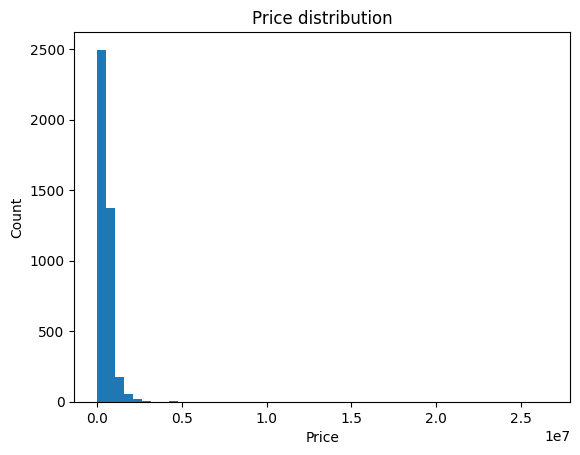

In [14]:
# shape, dtypes
print(df.shape)
print(df.dtypes)

# missing values
print(df.isnull().sum())

# basic stats
display(df.describe())

# check skew of target
display(df['price'].skew())
plt.hist(df['price'], bins=50)
plt.title('Price distribution')
plt.xlabel('Price'); plt.ylabel('Count')
plt.show()


In [15]:
# feature engineering
df['yr_built'] = df['yr_built'].fillna(0).astype(int)
df['age'] = 2025 - df['yr_built']      # or use current year
df['renovated_flag'] = (df['yr_renovated'] > 0).astype(int)

# pick features
features = ['sqft_living','sqft_lot','bedrooms','bathrooms','floors','waterfront',
            'view','condition','sqft_above','sqft_basement','age','renovated_flag']
X = df[features]
y = df['price']


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [17]:
num_features = X.select_dtypes(include=[np.number]).columns.tolist()  # list of numeric
# if you have categorical features:
# cat_features = ['city', 'state']  # example

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    # ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])


In [18]:
pipe_lr = Pipeline([
    ('pre', preprocessor),
    ('lr', LinearRegression())
])
pipe_lr.fit(X_train, y_train)
pred = pipe_lr.predict(X_test)

def print_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true,y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true,y_pred)
    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.4f}")

print_metrics(y_test, pred)


MAE: 167423.32, RMSE: 256026.88, R2: 0.3747


In [19]:
pipe_rf = Pipeline([
    ('pre', preprocessor),
    ('rf', RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20, None],
    'rf__min_samples_split': [2, 5]
}

grid = GridSearchCV(pipe_rf, param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
best = grid.best_estimator_
pred_rf = best.predict(X_test)
print_metrics(y_test, pred_rf)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'rf__max_depth': 10, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
MAE: 168148.57, RMSE: 263860.03, R2: 0.3359


In [20]:
# If you install xgboost in Colab: !pip install xgboost
from xgboost import XGBRegressor
pipe_xgb = Pipeline([('pre', preprocessor), ('xgb', XGBRegressor(tree_method='hist', n_jobs=-1, random_state=42))])
pipe_xgb.fit(X_train, y_train)
print_metrics(y_test, pipe_xgb.predict(X_test))


MAE: 171663.41, RMSE: 281003.34, R2: 0.2468


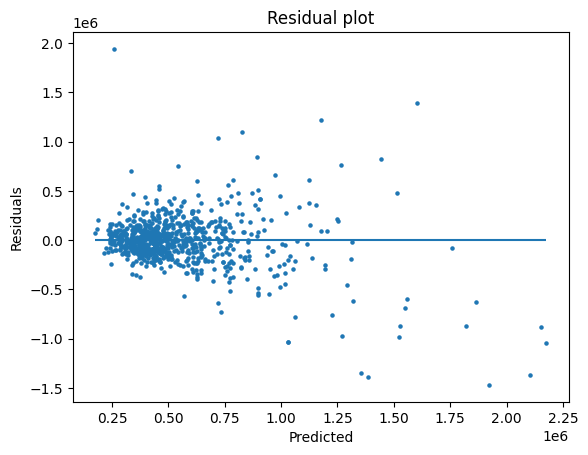

sqft_living 0.46591521787099477
age 0.18718184490898546
sqft_above 0.1026606719511849
sqft_lot 0.06299040177709014
sqft_basement 0.04296788033111936
bathrooms 0.04049384872237713
condition 0.034331531479409386
floors 0.018991406598073208
bedrooms 0.01445013093219322
view 0.014312798661440364


In [21]:
# residuals
preds = best.predict(X_test)
residuals = y_test - preds
plt.scatter(preds, residuals, s=5)
plt.hlines(0, xmin=preds.min(), xmax=preds.max())
plt.xlabel('Predicted'); plt.ylabel('Residuals'); plt.title('Residual plot')
plt.show()

# feature importances (RandomForest)
fi = best.named_steps['rf'].feature_importances_
for f, imp in sorted(zip(num_features, fi), key=lambda x: -x[1])[:10]:
    print(f, imp)


In [22]:
joblib.dump(best, 'house_price_model.joblib')
# then download in Colab:
from google.colab import files
files.download('house_price_model.joblib')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
sample = X_test.iloc[0:1]
pred_price = best.predict(sample)
print("Predicted price:", pred_price[0])


Predicted price: 739052.501036589
